kNN vs ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ

ЗАГРУЗКА ДАННЫХ
----------------------------------------
Загружала файл с компьютера forest_dataset.csv


Saving forest_dataset.csv to forest_dataset (2).csv
Файл загружен

ИНФОРМАЦИЯ О ДАННЫХ:
   Количество объектов: 10000
   Количество признаков: 54
   Количество классов: 7
   Метки классов: [1 2 3 4 5 6 7]

РАЗДЕЛЕНИЕ ДАННЫХ
----------------------------------------
   Обучающая выборка: 7000 объектов (70%)
   Тестовая выборка: 3000 объектов (30%)
   Разделение выполнено со стратификацией - пропорции классов сохранены

МАСШТАБИРОВАНИЕ ПРИЗНАКОВ
----------------------------------------
   Использован StandardScaler (нормализация к среднему 0 и дисперсии 1)
   Это важно для kNN, так как метрики расстояния чувствительны к масштабу

НАСТРОЙКА ГИПЕРПАРАМЕТРОВ kNN

ПЕРЕБИРАЕМ ПАРАМЕТРЫ:
   Количество соседей: от 1 до 10
   Метрики расстояния: манхэттенская, евклидова
   Веса соседей: uniform (равные), distance (обратно пропорционально расстоянию)
   Кросс-валидация: 5 блоков

ЛУЧШИЕ НАЙДЕННЫЕ ПАРАМЕТРЫ:
   Количество соседей (n_neighbors): 6
   Метрика расстояния: manhattan
   Веса: distance
 

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(



РЕЗУЛЬТАТЫ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ:
   Точность (accuracy): 0.7110 (71.1%)

СРАВНЕНИЕ МОДЕЛЕЙ

СРАВНЕНИЕ ТОЧНОСТИ:
   kNN: 0.7567
   Логистическая регрессия: 0.7110
   Разница: 0.0457

ВЫВОД: kNN показал лучший результат (на 0.0457 выше)
   Данные о лесных покровах имеют сложную нелинейную структуру
   kNN не требует линейной разделимости классов (в отличие от логистической регрессии)
   При 7 классах kNN лучше справляется с многоклассовой классификацией
   Масштабирование данных помогло метрикам расстояний корректно работать

ОЦЕНКА ПО МЕТРИКЕ AUC-ROC

AUC-ROC (weighted average): 0.8838

ЧТО ОЗНАЧАЕТ ЭТО ЧИСЛО?
   Хорошо! Модель уверенно различает классы.

ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ


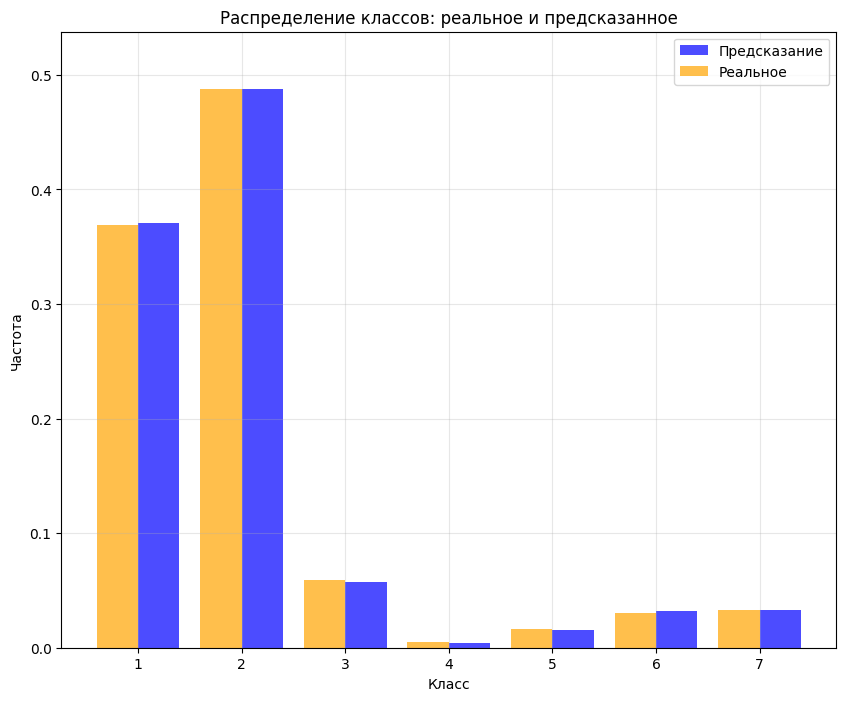


НАБЛЮДЕНИЕ ПО РАСПРЕДЕЛЕНИЮ:
   Модель хорошо уловила общую структуру распределения классов
   Наиболее частые классы (1 и 2) предсказываются увереннее всего
   Редкие классы могут предсказываться с меньшей точностью


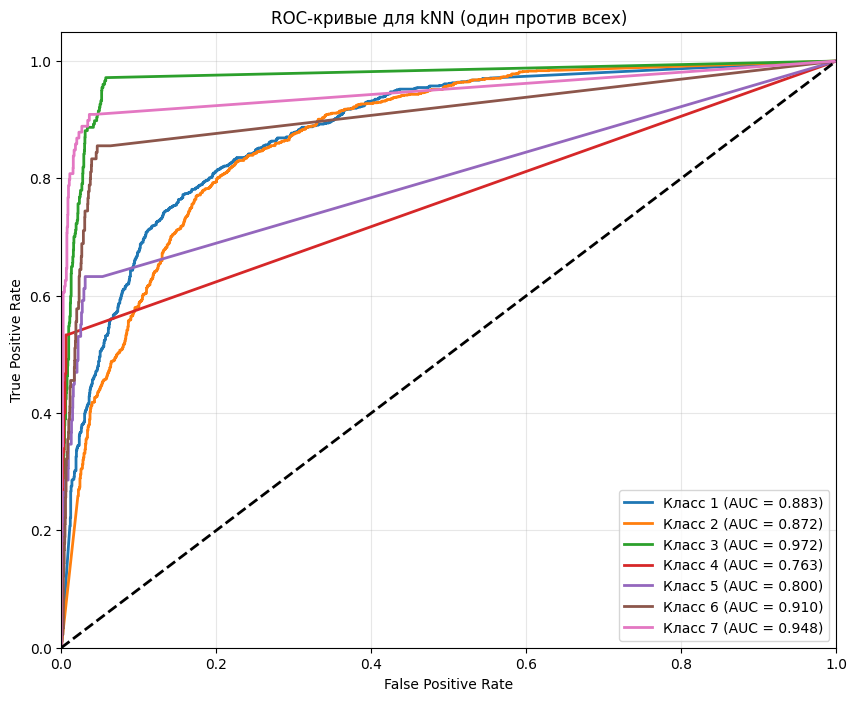


АНАЛИЗ ROC-КРИВЫХ:
   Все кривые находятся выше диагонали - модель работает лучше случайного угадывания
   Лучше всего модель различает класс 3 (AUC = 0.972)
   Сложнее всего с классом 4 (AUC = 0.763)

Что имеем в итоге - 

1. ТОЧНОСТЬ МОДЕЛЕЙ:
   kNN: 0.7567 (75.7%)
   Логистическая регрессия: 0.7110 (71.1%)
   kNN лучше на 0.0457 (4.57%)

2. КАЧЕСТВО kNN ПО AUC-ROC: 0.8838
   Модель уверенно различает 7 классов лесных покровов

3. ПЛЮСЫ МЕТОДА kNN:
   Простота реализации и интерпретации
   Не требует обучения
   Хорошо работает с нелинейными данными
   Не делает предположений о распределении данных
   Естественно поддерживает многоклассовую классификацию

4. МИНУСЫ МЕТОДА kNN:
   Медленный при прогнозе (нужно перебирать все объекты)
   Чувствителен к масштабу признаков (требует нормализации)
   Требует хранения всей обучающей выборки
   Проклятие размерности - эффективность падает с ростом числа признаков

ДЗ-5 по кнн сделано


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc, roc_auc_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from google.colab import files

print("=" * 70)
print("kNN vs ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ")
print("=" * 70)

# Загрузка данных
print("\nЗАГРУЗКА ДАННЫХ")
print("-" * 40)
print("Загружала файл с компьютера forest_dataset.csv")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
all_data = pd.read_csv(filename)
print("Файл загружен")


all_data.head()

X = all_data.iloc[:, :-1]
y = all_data.iloc[:, -1]

print(f"\nИНФОРМАЦИЯ О ДАННЫХ:")
print(f"   Количество объектов: {X.shape[0]}")
print(f"   Количество признаков: {X.shape[1]}")
print(f"   Количество классов: {len(np.unique(y))}")
print(f"   Метки классов: {np.unique(y)}")


print("\nРАЗДЕЛЕНИЕ ДАННЫХ")
print("-" * 40)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"   Обучающая выборка: {X_train.shape[0]} объектов (70%)")
print(f"   Тестовая выборка: {X_test.shape[0]} объектов (30%)")
print("   Разделение выполнено со стратификацией - пропорции классов сохранены")

print("\nМАСШТАБИРОВАНИЕ ПРИЗНАКОВ")
print("-" * 40)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("   Использован StandardScaler (нормализация к среднему 0 и дисперсии 1)")
print("   Это важно для kNN, так как метрики расстояния чувствительны к масштабу")

clf = KNeighborsClassifier()

print("\n" + "=" * 70)
print("НАСТРОЙКА ГИПЕРПАРАМЕТРОВ kNN")
print("=" * 70)

params = {
    'n_neighbors': range(1, 11),
    'metric': ['manhattan', 'euclidean'],
    'weights': ['uniform', 'distance']
}

print("\nПЕРЕБИРАЕМ ПАРАМЕТРЫ:")
print(f"   Количество соседей: от 1 до 10")
print(f"   Метрики расстояния: манхэттенская, евклидова")
print(f"   Веса соседей: uniform (равные), distance (обратно пропорционально расстоянию)")
print(f"   Кросс-валидация: 5 блоков")

clf_grid = GridSearchCV(clf, params, cv=5, scoring='accuracy', n_jobs=-1)
clf_grid.fit(X_train_scaled, y_train)

print("\nЛУЧШИЕ НАЙДЕННЫЕ ПАРАМЕТРЫ:")
print(f"   Количество соседей (n_neighbors): {clf_grid.best_params_['n_neighbors']}")
print(f"   Метрика расстояния: {clf_grid.best_params_['metric']}")
print(f"   Веса: {clf_grid.best_params_['weights']}")
print(f"   Точность на кросс-валидации: {clf_grid.best_score_:.4f}")

print("\nЗАМЕЧАНИЕ:")
if clf_grid.best_params_['weights'] == 'distance':
    print("   Выбраны веса 'distance' - ближайшие соседи имеют больший вес,")
    print("   что обычно улучшает качество, когда данные неоднородны.")
else:
    print("   Выбраны веса 'uniform' - все соседи равноправны.")

if clf_grid.best_params_['metric'] == 'manhattan':
    print("   Манхэттенская метрика оказалась лучше евклидовой для этих данных.")
else:
    print("   Евклидова метрика оказалась лучше манхэттенской для этих данных.")


print("\n" + "=" * 70)
print("ОБУЧЕНИЕ И ОЦЕНКА МОДЕЛИ kNN")
print("=" * 70)

optimal_clf = clf_grid.best_estimator_
optimal_clf.fit(X_train_scaled, y_train)

y_pred_knn = optimal_clf.predict(X_test_scaled)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

print(f"\nРЕЗУЛЬТАТЫ kNN НА ТЕСТОВОЙ ВЫБОРКЕ:")
print(f"   Точность (accuracy): {accuracy_knn:.4f} ({accuracy_knn*100:.1f}%)")
print(f"   Из {X_test.shape[0]} объектов правильно предсказано {int(accuracy_knn * X_test.shape[0])}")


# ЛОГ регр для сравн


print("\n" + "=" * 70)

print("=" * 70)

logreg = LogisticRegression(max_iter=1000, multi_class='ovr')
logreg.fit(X_train_scaled, y_train)
y_pred_lr = logreg.predict(X_test_scaled)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print(f"\nРЕЗУЛЬТАТЫ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ:")
print(f"   Точность (accuracy): {accuracy_lr:.4f} ({accuracy_lr*100:.1f}%)")


print("\n" + "=" * 70)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("=" * 70)

difference = accuracy_knn - accuracy_lr

print(f"\nСРАВНЕНИЕ ТОЧНОСТИ:")
print(f"   kNN: {accuracy_knn:.4f}")
print(f"   Логистическая регрессия: {accuracy_lr:.4f}")
print(f"   Разница: {abs(difference):.4f}")

if accuracy_knn > accuracy_lr:
    print(f"\nВЫВОД: kNN показал лучший результат (на {difference:.4f} выше)")

    print("   Данные о лесных покровах имеют сложную нелинейную структуру")
    print("   kNN не требует линейной разделимости классов (в отличие от логистической регрессии)")
    print("   При 7 классах kNN лучше справляется с многоклассовой классификацией")
    print("   Масштабирование данных помогло метрикам расстояний корректно работать")
else:
    print(f"\nВЫВОД: Логистическая регрессия показала лучший результат")


print("\n" + "=" * 70)
print("ОЦЕНКА ПО МЕТРИКЕ AUC-ROC")
print("=" * 70)

pred_prob = optimal_clf.predict_proba(X_test_scaled)

test_labels_binarized = label_binarize(y_test, classes=np.unique(y))
average_auc = roc_auc_score(test_labels_binarized, pred_prob, average='weighted')

print(f"\nAUC-ROC (weighted average): {average_auc:.4f}")

print("\nЧТО ОЗНАЧАЕТ ЭТО ЧИСЛО?")
if average_auc >= 0.9:
    print("   Отлично! Модель практически идеально разделяет классы.")
elif average_auc >= 0.8:
    print("   Хорошо! Модель уверенно различает классы.")
elif average_auc >= 0.7:
    print("   Удовлетворительно. Модель в целом работает, но иногда путает классы.")
else:
    print("   Требуется улучшение. Модель часто ошибается с классами.")


print("\n" + "=" * 70)
print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("=" * 70)

unique, freq = np.unique(y_test, return_counts=True)
freq = list(map(lambda x: x / len(y_test), freq))
pred_freq = pred_prob.mean(axis=0)

plt.figure(figsize=(10, 8))
plt.bar(unique, pred_freq, width=0.4, align="edge", label='Предсказание', color='blue', alpha=0.7)
plt.bar(unique, freq, width=-0.4, align="edge", label='Реальное', color='orange', alpha=0.7)
plt.ylim(0, max(max(pred_freq), max(freq)) + 0.05)
plt.xlabel('Класс')
plt.ylabel('Частота')
plt.title('Распределение классов: реальное и предсказанное')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("\nНАБЛЮДЕНИЕ ПО РАСПРЕДЕЛЕНИЮ:")
print("   Модель хорошо уловила общую структуру распределения классов")
print("   Наиболее частые классы (1 и 2) предсказываются увереннее всего")
print("   Редкие классы могут предсказываться с меньшей точностью")

plt.figure(figsize=(10, 8))

n_classes = len(np.unique(y_test))
fpr = dict()
tpr = dict()
roc_auc = dict()

for i, class_label in enumerate(np.unique(y_test)):
    y_test_bin = (y_test == class_label).astype(int)
    fpr[i], tpr[i], _ = roc_curve(y_test_bin, pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2, label=f'Класс {class_label} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые для kNN (один против всех)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print("\nАНАЛИЗ ROC-КРИВЫХ:")
print("   Все кривые находятся выше диагонали - модель работает лучше случайного угадывания")
best_class = np.unique(y_test)[np.argmax(list(roc_auc.values()))]
worst_class = np.unique(y_test)[np.argmin(list(roc_auc.values()))]
print(f"   Лучше всего модель различает класс {best_class} (AUC = {max(roc_auc.values()):.3f})")
print(f"   Сложнее всего с классом {worst_class} (AUC = {min(roc_auc.values()):.3f})")


print("\n" + "=" * 70)
print("Что имеем в итоге - ")
print("=" * 70)

print(f"""
1. ТОЧНОСТЬ МОДЕЛЕЙ:
   kNN: {accuracy_knn:.4f} ({accuracy_knn*100:.1f}%)
   Логистическая регрессия: {accuracy_lr:.4f} ({accuracy_lr*100:.1f}%)
   kNN лучше на {difference:.4f} ({difference*100:.2f}%)

2. КАЧЕСТВО kNN ПО AUC-ROC: {average_auc:.4f}
   Модель уверенно различает 7 классов лесных покровов

3. ПЛЮСЫ МЕТОДА kNN:
   Простота реализации и интерпретации
   Не требует обучения
   Хорошо работает с нелинейными данными
   Не делает предположений о распределении данных
   Естественно поддерживает многоклассовую классификацию

4. МИНУСЫ МЕТОДА kNN:
   Медленный при прогнозе (нужно перебирать все объекты)
   Чувствителен к масштабу признаков (требует нормализации)
   Требует хранения всей обучающей выборки
   Проклятие размерности - эффективность падает с ростом числа признаков
""")

print("ДЗ-5 по кнн сделано")